# GeoParquet to GeoCroissant Support

<img src="../asset/GeoCroissant.jpg" alt="GeoCroissant" width="150" style="float: right; margin-left: 50px;">

In this notebook, we download NAIP STAC items, convert them to GeoParquet using `stac-geoparquet`, and then programmatically generate a MLCommons GeoCroissant metadata.

In [ ]:
!pip install -q pystac-client stac-geoparquet pyarrow mlcroissant

### 1. Download NAIP items

In [1]:
import json
from pathlib import Path
import pystac_client

max_items = 100
naip_json_path = Path("naip.jsonl")
if naip_json_path.exists():
    print(f"Using existing {naip_json_path}")
else:
    catalog = pystac_client.Client.open("https://planetarycomputer.microsoft.com/api/stac/v1")
    items_iter = catalog.get_collection("naip").get_items()
    with open(naip_json_path, "w") as f:
        count = 0
        for item in items_iter:
            json.dump(item.to_dict(), f, separators=(",", ":"))
            f.write("\n")
            count += 1
            if count >= max_items:
                break
    print(f"Downloaded {max_items} STAC items to {naip_json_path}")

Downloaded 100 STAC items to naip.jsonl


### 2. Convert to GeoParquet

In [2]:
import stac_geoparquet.arrow
import pyarrow.parquet as pq

naip_parquet_path = "naip.parquet"
stac_geoparquet.arrow.parse_stac_ndjson_to_parquet(naip_json_path, naip_parquet_path)
print(f"Saved GeoParquet to {naip_parquet_path}")

table = pq.read_table(naip_parquet_path)
print("GeoParquet Schema:")
print(table.schema)

Saved GeoParquet to naip.parquet
GeoParquet Schema:
assets: struct<image: struct<eo:bands: list<element: struct<common_name: string, description: string, name:  (... 378 chars omitted)
  child 0, image: struct<eo:bands: list<element: struct<common_name: string, description: string, name: string>>, href (... 68 chars omitted)
      child 0, eo:bands: list<element: struct<common_name: string, description: string, name: string>>
          child 0, element: struct<common_name: string, description: string, name: string>
              child 0, common_name: string
              child 1, description: string
              child 2, name: string
      child 1, href: string
      child 2, roles: list<element: string>
          child 0, element: string
      child 3, title: string
      child 4, type: string
  child 1, rendered_preview: struct<href: string, rel: string, roles: list<element: string>, title: string, type: string>
      child 0, href: string
      child 1, rel: string
      child 2, r

### 3. Extract Metadata dynamically from GeoParquet
We map the Parquet schema to GeoCroissant semantics by extracting bounding boxes and time ranges dynamically.

In [3]:
import pyarrow.compute as pc
import pyarrow.parquet as pq
import json, datetime

# Temporal coverage 
min_dt = pc.min(table["datetime"]).as_py()
max_dt = pc.max(table["datetime"]).as_py()
temporal_coverage = f"{min_dt.strftime('%Y-%m-%d')}/{max_dt.strftime('%Y-%m-%d')}"

# Spatial bounding box (minY minX maxY maxX)
min_x = pc.min(pc.struct_field(table["bbox"], [0])).as_py()
min_y = pc.min(pc.struct_field(table["bbox"], [1])).as_py()
max_x = pc.max(pc.struct_field(table["bbox"], [2])).as_py()
max_y = pc.max(pc.struct_field(table["bbox"], [3])).as_py()
spatial_box = f"{min_y} {min_x} {max_y} {max_x}"

# Collection name & URLs from parquet
collection_name = table["collection"][0].as_py() if "collection" in table.schema.names else "unknown"
dataset_name = f"{collection_name}_geoparquet"

collection_url = ""
if "links" in table.schema.names:
    for link in (table["links"][0].as_py() or []):
        if isinstance(link, dict) and link.get("rel") == "collection":
            collection_url = link.get("href", "")
            break

# Spatial resolution from gsd column
gsd_value = None
if "gsd" in table.schema.names:
    gsd_value = round(float(pc.approximate_median(table["gsd"]).as_py()), 3)

# Native CRS from GeoParquet file metadata
crs_str = "EPSG:4326"
geo_meta_raw = pq.read_metadata(naip_parquet_path).metadata.get(b"geo")
if geo_meta_raw:
    geo_meta = json.loads(geo_meta_raw)
    crs_obj = geo_meta.get("columns", {}).get("geometry", {}).get("crs")
    if isinstance(crs_obj, dict):
        crs_id = crs_obj.get("id", {})
        crs_str = f"{crs_id.get('authority', 'EPSG')}:{crs_id.get('code', 4326)}"
    elif isinstance(crs_obj, str):
        crs_str = crs_obj

# Providers & license from parquet
license_str = "Unknown"
creators = []
if "providers" in table.schema.names:
    for p in (table["providers"][0].as_py() or []):
        if not isinstance(p, dict):
            continue
        roles = p.get("roles", [])
        if "licensor" in roles:
            license_str = p.get("url", "Unknown")
        if any(r in roles for r in ("producer", "licensor", "host")):
            creators.append({"@type": "Organization", "name": p.get("name", ""), "url": p.get("url", "")})

# Spectral bands from eo:bands inside assets
_wl_lookup = {
    "red":    {"center": 660,  "bw": 60},
    "green":  {"center": 560,  "bw": 80},
    "blue":   {"center": 470,  "bw": 100},
    "nir":    {"center": 825,  "bw": 150},
    "swir16": {"center": 1610, "bw": 90},
    "swir22": {"center": 2200, "bw": 180},
}
spectral_bands = []
band_names = []
try:
    first_row = table.slice(0, 1).to_pydict()
    assets = (first_row.get("assets") or [{}])[0] or {}
    image_asset = assets.get("image") or {}
    for b in (image_asset.get("eo:bands") or []):
        name = b.get("name") or b.get("common_name", "Unknown")
        common = (b.get("common_name") or "").lower()
        entry = {"@type": "geocr:SpectralBand", "name": name}
        if common in _wl_lookup:
            wl = _wl_lookup[common]
            entry["geocr:centerWavelength"] = {"@type": "QuantitativeValue", "value": wl["center"], "unitText": "nm"}
            entry["geocr:bandwidth"]        = {"@type": "QuantitativeValue", "value": wl["bw"],     "unitText": "nm"}
        spectral_bands.append(entry)
        band_names.append(name)
except Exception as e:
    print(f"Warning: could not extract eo:bands: {e}")

print(f"Collection     : {collection_name}")
print(f"Dataset URL    : {collection_url}")
print(f"GSD            : {gsd_value} m")
print(f"CRS            : {crs_str}")
print(f"License        : {license_str}")
print(f"Bands          : {band_names}")
print(f"Temporal       : {temporal_coverage}")
print(f"Spatial box    : {spatial_box}")

Collection     : naip
Dataset URL    : https://planetarycomputer.microsoft.com/api/stac/v1/collections/naip
GSD            : 0.6 m
CRS            : EPSG:4326
License        : https://www.fsa.usda.gov/programs-and-services/aerial-photography/imagery-programs/naip-imagery/
Bands          : ['Red', 'Green', 'Blue', 'NIR']
Temporal       : 2023-11-17/2023-11-17
Spatial box    : 45.059225 -116.066472 49.065003 -113.182469


### 4. Construct the GeoCroissant JSON-LD
Here we assign the table as the `Distribution` and define fields mapped to the Parquet columns.

In [4]:
import hashlib, datetime

# Compute sha256 of the parquet file
sha256_hash = hashlib.sha256()
with open(naip_parquet_path, "rb") as f:
    for chunk in iter(lambda: f.read(8192), b""):
        sha256_hash.update(chunk)
parquet_sha256 = sha256_hash.hexdigest()
print(f"SHA256: {parquet_sha256}")

CONTEXT = {
    "@language": "en",
    "@vocab": "https://schema.org/",
    "citeAs": "cr:citeAs",
    "column": "cr:column",
    "conformsTo": "dct:conformsTo",
    "cr": "http://mlcommons.org/croissant/",
    "geocr": "http://mlcommons.org/croissant/geo/",
    "rai": "http://mlcommons.org/croissant/RAI/",
    "dct": "http://purl.org/dc/terms/",
    "sc": "https://schema.org/",
    "data": {"@id": "cr:data", "@type": "@json"},
    "examples": {"@id": "cr:examples", "@type": "@json"},
    "dataBiases": "cr:dataBiases",
    "dataCollection": "cr:dataCollection",
    "dataType": {"@id": "cr:dataType", "@type": "@vocab"},
    "extract": "cr:extract",
    "field": "cr:field",
    "fileProperty": "cr:fileProperty",
    "fileObject": "cr:fileObject",
    "fileSet": "cr:fileSet",
    "format": "cr:format",
    "includes": "cr:includes",
    "isLiveDataset": "cr:isLiveDataset",
    "jsonPath": "cr:jsonPath",
    "key": "cr:key",
    "md5": "cr:md5",
    "equivalentProperty": "cr:equivalentProperty",
    "parentField": "cr:parentField",
    "path": "cr:path",
    "personalSensitiveInformation": "cr:personalSensitiveInformation",
    "recordSet": "cr:recordSet",
    "references": "cr:references",
    "regex": "cr:regex",
    "repeated": "cr:repeated",
    "replace": "cr:replace",
    "samplingRate": "cr:samplingRate",
    "separator": "cr:separator",
    "source": "cr:source",
    "subField": "cr:subField",
    "transform": "cr:transform",
}

# Build fields list from parquet schema
parquet_fields = [
    {"@type": "cr:Field", "@id": f"{collection_name}_items/id",
     "name": f"{collection_name}_items/id", "dataType": "sc:Text",
     "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": "id"}}},
    {"@type": "cr:Field", "@id": f"{collection_name}_items/geometry",
     "name": f"{collection_name}_items/geometry",
     "description": "WKB binary of the item geometry",
     "dataType": "sc:Text",
     "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": "geometry"}}},
    {"@type": "cr:Field", "@id": f"{collection_name}_items/image_url",
     "name": f"{collection_name}_items/image_url", "dataType": "sc:URL",
     "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": "assets.image.href"}},
     "geocr:bandConfiguration": {
         "@type": "geocr:BandConfiguration",
         "geocr:totalBands": len(band_names),
         "geocr:bandNameList": band_names,
     }},
    {"@type": "cr:Field", "@id": f"{collection_name}_items/datetime",
     "name": f"{collection_name}_items/datetime",
     "description": "Acquisition datetime (UTC ms epoch)",
     "dataType": "sc:DateTime",
     "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": "datetime"}}},
    {"@type": "cr:Field", "@id": f"{collection_name}_items/gsd",
     "name": f"{collection_name}_items/gsd",
     "description": "Ground sample distance in metres",
     "dataType": "sc:Float",
     "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": "gsd"}}},
    {"@type": "cr:Field", "@id": f"{collection_name}_items/proj_code",
     "name": f"{collection_name}_items/proj_code",
     "description": "Native projected CRS of the imagery tile",
     "dataType": "sc:Text",
     "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": "proj:code"}}},
    {"@type": "cr:Field", "@id": f"{collection_name}_items/thumbnail_url",
     "name": f"{collection_name}_items/thumbnail_url",
     "description": "Thumbnail URL for the imagery tile",
     "dataType": "sc:URL",
     "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": "assets.thumbnail.href"}}},
]

# Add any collection-specific property columns (e.g. naip:state, naip:year)
for col in table.schema.names:
    if ":" in col and not col.startswith("proj") and not col.startswith("eo"):
        safe_id = col.replace(":", "_")
        parquet_fields.append({
            "@type": "cr:Field",
            "@id": f"{collection_name}_items/{safe_id}",
            "name": f"{collection_name}_items/{safe_id}",
            "description": f"STAC property: {col}",
            "dataType": "sc:Text",
            "source": {"fileObject": {"@id": f"{collection_name}.parquet"}, "extract": {"column": col}},
        })

# Assemble the GeoCroissant document
geocroissant_json = {
    "@context": CONTEXT,
    "@type": "sc:Dataset",
    "name": dataset_name,
    "description": f"{collection_name.upper()} dataset accessed via STAC and converted to GeoParquet.",
    "url": collection_url,
    "citeAs": f"@dataset{{{collection_name}, title={{{collection_name} GeoParquet dataset}}}}",
    "datePublished": datetime.datetime.now().strftime("%Y-%m-%d"),
    "version": "1.0",
    "license": license_str,
    "conformsTo": [
        "http://mlcommons.org/croissant/1.1",
        "http://mlcommons.org/croissant/geo/1.0",
    ],
    "temporalCoverage": temporal_coverage,
    "geocr:coordinateReferenceSystem": crs_str,
    "spatialCoverage": {
        "@type": "Place",
        "geo": {"@type": "GeoShape", "box": spatial_box},
    },
    "distribution": [{
        "@type": "cr:FileObject",
        "@id": f"{collection_name}.parquet",
        "name": f"{collection_name}.parquet",
        "description": f"GeoParquet representation of {collection_name} STAC items",
        "contentUrl": f"./{collection_name}.parquet",
        "encodingFormat": "application/vnd.apache.parquet",
        "sha256": parquet_sha256,
    }],
    "recordSet": [{
        "@type": "cr:RecordSet",
        "@id": f"{collection_name}_items",
        "name": f"{collection_name}_items",
        "description": f"STAC items for the {collection_name} collection.",
        "field": parquet_fields,
    }],
}

# Optional fields added only when data is available
if gsd_value is not None:
    geocroissant_json["geocr:spatialResolution"] = {
        "@type": "QuantitativeValue", "value": gsd_value, "unitText": "m"
    }
if spectral_bands:
    geocroissant_json["geocr:spectralBandMetadata"] = spectral_bands
if creators:
    geocroissant_json["creator"] = creators[0] if len(creators) == 1 else creators

# Write the GeoCroissant JSON-LD to file
with open("naip_croissant.json", "w") as f:
    json.dump(geocroissant_json, f, indent=2)
print("Saved naip_croissant.json")

SHA256: 188c439706c6d69a31f4857f72fec3f1753031fc72565b7d9c950c990db538fd
Saved naip_croissant.json


### Validate and Inspect GeoCroissant Metadata
Finally, we check with the mlcroissant CLI validator.

In [6]:
!mlcroissant validate --jsonld=naip_croissant.json

I0224 02:14:24.652680 17796 validate.py:53] Done.


### 5. Visualize the GeoCroissant Metadata

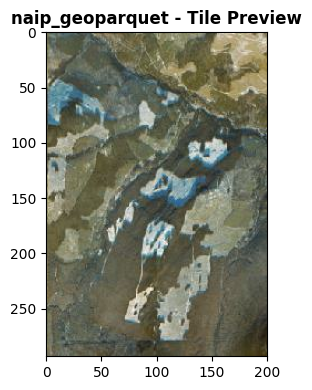

In [9]:
import json
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt
import pyarrow.parquet as pq

# Load GeoCroissant metadata
with open("naip_croissant.json") as f:
    croissant_meta = json.load(f)

# Extract parquet file path from the distribution
parquet_file = next(
    dist.get("contentUrl", "").replace("./", "")
    for dist in croissant_meta.get("distribution", [])
    if dist.get("encodingFormat") == "application/vnd.apache.parquet"
)

# Load the parquet table
table = pq.read_table(parquet_file)

# Find the thumbnail field from recordSet
thumbnail_field = next(
    field for field in croissant_meta["recordSet"][0]["field"]
    if "thumbnail" in field.get("name", "").lower()
)
thumbnail_column = thumbnail_field["source"]["extract"]["column"]

# Extract first thumbnail URL from the data
thumb_url = next(
    row.get("assets", {}).get("thumbnail", {}).get("href")
    for row in table.to_pylist()
    if row and row.get("assets", {}).get("thumbnail")
)

# Visualize using rasterio
with rasterio.open(f"/vsicurl/{thumb_url}") as src:
    fig, ax = plt.subplots(figsize=(4, 4))
    show(src, ax=ax, title=f"{croissant_meta['name']} - Tile Preview")
    plt.tight_layout()
    plt.show()